In [1]:
import pandas as pd
import numpy as np
import re
import pymorphy3
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC

In [2]:
path = "C:/Users/igrew/OneDrive/Desktop/Course Work/Datasets/ua_news_test_theme.csv"
df = pd.read_csv(path)
df = df.sample(n=30000, random_state=41).dropna()
df.head()

,title,text,tags,target
20285,"Бойовики ""ДНР"" дають місцевим постріляти за г...",16 січня в районі Трикотажної фабрики Горлівки...,|автомати|Новини|гроші|ДНР|стрільба|,політика
26353,На вибори потрібно майже 760 млн грн - Центрв...,Відповідне рішення було прийняте на засіданні ...,|вибори|ЦВК|вартість|Новини|,політика
21227,"ОФІЦІЙНО. Названі міста, у яких збірна України...",Виконавчий комітет Української асоціації футбо...,Футбол|Ліга націй|Уєфа|збірна України з футбол...,спорт
19287,Індонезію сколихнув потужний землетрус: постр...,В результаті стихійного лиха зруйновано близьк...,|магнітуда|руйнування|Індонезія|цунамі|Новини|...,новини
26183,ВПК-Агро – Кремінь. Дивитися онлайн. LIVE тран...,"У середу, 16 вересня, відбудеться матч другого...",Футбол|Кубок України|Впк-агро|Кремінь Кременчу...,спорт


In [3]:
print("Unique targets:")
print(df['target'].unique())
print("\nValue counts:")
print(df['target'].value_counts())
print(f"\nNumber of nans: {df['target'].isnull().sum().sum()}")

Unique targets:
['політика' 'спорт' 'новини' 'технології' 'бізнес']

Value counts:
target
політика      10075
спорт          7214
новини         6210
бізнес         3640
технології     2861
Name: count, dtype: int64

Number of nans: 0


In [4]:
all_text = (
    df['title'].fillna('') + ' ' +
    df['text'].fillna('') + ' ' +
    df['tags'].fillna('').replace('|', ' ').fillna('')
)
all_text = all_text.to_frame(name='all_text')
all_text

,all_text
20285,"Бойовики ""ДНР"" дають місцевим постріляти за г..."
26353,На вибори потрібно майже 760 млн грн - Центрв...
21227,"ОФІЦІЙНО. Названі міста, у яких збірна України..."
19287,Індонезію сколихнув потужний землетрус: постр...
26183,ВПК-Агро – Кремінь. Дивитися онлайн. LIVE тран...
...,...
10343,Навальний подав позов проти генпрокурора Моск...
2449,ЗМІ: Російські військові літаки тинялися і бі...
15887,У Барселоні понад сто тисяч демонстрантів вим...
28208,"У Києві ""Деу"" протаранив два автомобілі і заг..."


In [5]:
with open('../stopwords_ua.txt', 'r', encoding='utf-8') as f:
    content = f.read()
    stopwords = content.split()
print(stopwords[:150])

['а', 'аби', 'абиде', 'абиким', 'абикого', 'абиколи', 'абикому', 'абикуди', 'абихто', 'абичий', 'абичийого', 'абичийому', 'абичим', 'абичию', 'абичия', 'абичиє', 'абичиєму', 'абичиєю', 'абичиєї', 'абичиї', 'абичиїй', 'абичиїм', 'абичиїми', 'абичиїх', 'абичого', 'абичому', 'абищо', 'абияка', 'абияке', 'абиякий', 'абияким', 'абиякими', 'абияких', 'абиякого', 'абиякому', 'абиякою', 'абиякої', 'абияку', 'абиякі', 'абиякій', 'абиякім', 'або', 'абощо', 'авжеж', 'авось', 'ага', 'ад', 'адже', 'аж', 'ажень', 'аз', 'ай', 'але', 'ало', 'амінь', 'ант', 'ану', 'ані', 'аніде', 'аніж', 'анізащо', 'аніким', 'анікого', 'анікогісінько', 'аніколи', 'анікому', 'аніскільки', 'аніхто', 'анічим', 'анічого', 'анічогісінько', 'анічому', 'аніщо', 'аніяка', 'аніяке', 'аніякий', 'аніяким', 'аніякими', 'аніяких', 'аніякого', 'аніякому', 'аніякою', 'аніякої', 'аніяку', 'аніякі', 'аніякій', 'аніякім', 'аніякісенька', 'аніякісеньке', 'аніякісенький', 'аніякісеньким', 'аніякісенькими', 'аніякісеньких', 'аніякісенького

In [6]:
tqdm.pandas()

In [7]:
def filtering(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'[^\w\s]', '', sentence)
    words = sentence.split()
    clean_text = [word for word in words if word not in stopwords]
    return ' '.join(clean_text)

all_text['all_text'] = all_text['all_text'].progress_apply(filtering)
all_text

100%|██████████| 30000/30000 [02:07<00:00, 234.65it/s]


,all_text
20285,бойовики днр дають місцевим постріляти гроші 1...
26353,вибори 760 млн грн центрвиборчком відповідне р...
21227,офіційно названі міста збірна україни зіграє л...
19287,індонезію сколихнув потужний землетрус постраж...
26183,впкагро кремінь дивитися онлайн live трансляці...
...,...
10343,навальний подав позов генпрокурора москви пові...
2449,змі російські військові літаки тинялися кордон...
15887,барселоні сто демонстрантів вимагали звільненн...
28208,києві деу протаранив автомобілі загорівся пові...


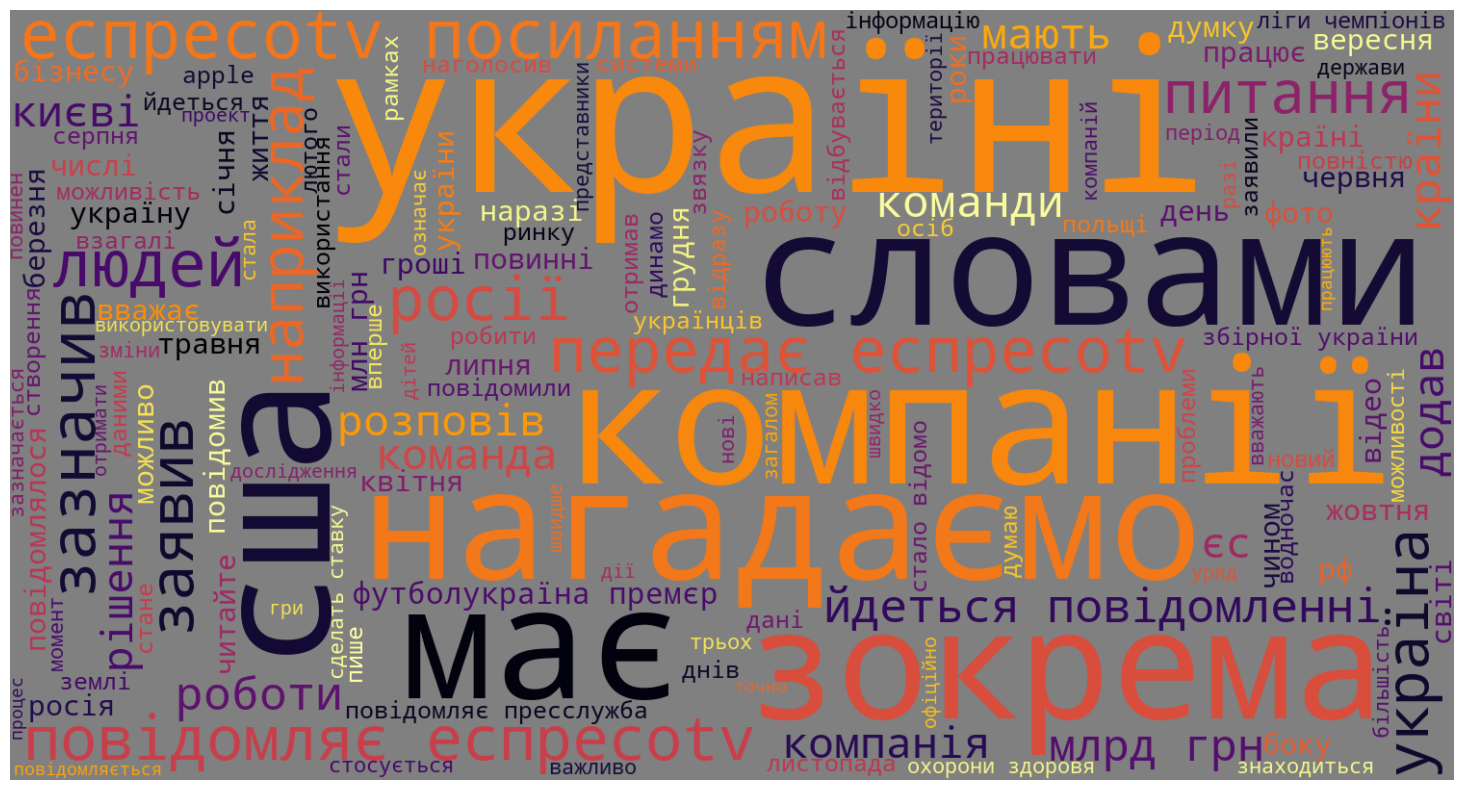

In [8]:
text_for_wc = ' '.join(all_text['all_text'])
wordcloud = WordCloud(
    height=800,
    width=1500,
    prefer_horizontal=0.6,
    min_font_size=10,
    max_font_size=220,
    random_state=42,
    colormap='inferno',
    background_color='grey',
    max_words=150
).generate(text_for_wc)

plt.figure(figsize=(15,8))
plt.axis(False)
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout()
plt.show()

In [9]:
morph = pymorphy3.MorphAnalyzer(lang='uk')

def lemmatize_text(sentence):
    words = sentence.split()
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return ' '.join(lemmas)

all_text['all_text'] = all_text['all_text'].progress_apply(lemmatize_text)
all_text

100%|██████████| 30000/30000 [04:50<00:00, 103.27it/s]


,all_text
20285,бойовик днр давати місцевий постріляти гріш 16...
26353,вибори 760 млн грн центрвиборчком відповідний ...
21227,офіційно названий місто збірний україна зіграт...
19287,індонезія сколихнути потужний землетрус постра...
26183,впкагро кремінь дивитися онлайн live трансляці...
...,...
10343,навальний подати позов генпрокурор москва пові...
2449,змі російський військовий літак тинятися кордо...
15887,барселона сто демонстрант вимагати звільнення ...
28208,кий деу протаранити автомобіль загорітися пові...


In [10]:
X = all_text['all_text'].values
Y = df['target'].values
print(f"X: {X[:2]}")
print(f"Y: {Y[:2]}")
print(f"X shape: {X.shape}")
print(f"Y shape {Y.shape}")

X: ['бойовик днр давати місцевий постріляти гріш 16 січень район трикотажний фабрика горлівка ввечері ставитися цікавий повідомляти журналіст микита синіцин facebook передавати еспресоtv місцевий житель знайомий боєць самопроголошений днр попросити постріляти автомат калашников дати постріляти 100 російський рубль ріжок 30 патрон розповісти горловчанин патрон бойовик гроші чесно кажучи знати наскільки правда часть явище стрілянина автоматичний зброя горлівка часть явище наслідок бій стрілянина чутний набагато ближче лінія фронт писати синіцин автоматиновинигрошіднрстрільба'
 'вибори 760 млн грн центрвиборчком відповідний рішення прийнятий засідання цвк повідомляти еспресоtv посилання укрінформ кошторис проведення нинішній вибори необхідно 957 млн 792 тис 700 грн виборицвквартістьновина']
Y: ['політика' 'політика']
X shape: (30000,)
Y shape (30000,)


In [11]:
vectorizer = TfidfVectorizer(
    max_features=7000,  
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,  
    use_idf=True,
    smooth_idf=True
)

X = vectorizer.fit_transform(X)
print(f"TF-IDF векторизація завершена: {X.shape[1]} ознак")

TF-IDF векторизація завершена: 7000 ознак


In [12]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2316996 stored elements and shape (30000, 7000)>
  Coords	Values
  (0, 714)	0.17859752991069675
  (0, 1810)	0.2183181531130166
  (0, 1659)	0.09897211793028074
  (0, 3522)	0.15924957108746288
  (0, 1643)	0.10322115834219008
  (0, 52)	0.09359733414058632
  (0, 6046)	0.09619996910356843
  (0, 5217)	0.08996011746690308
  (0, 6434)	0.1625900352041369
  (0, 1550)	0.2797759341965895
  (0, 869)	0.1270675701969181
  (0, 5841)	0.1108415157817035
  (0, 6622)	0.11546137859909861
  (0, 4442)	0.05007640253806552
  (0, 2122)	0.09806018916577212
  (0, 3343)	0.16150113967729351
  (0, 259)	0.08610335454310337
  (0, 4269)	0.07194258270584956
  (0, 2072)	0.06358114072979558
  (0, 2104)	0.11099864512474317
  (0, 2524)	0.13685589135962115
  (0, 739)	0.11803250431372979
  (0, 4601)	0.12403807890425664
  (0, 434)	0.15995628945461715
  (0, 1677)	0.09831717639474122
  :	:
  (29999, 4554)	0.13048629164861003
  (29999, 4956)	0.0974495504804144
  (29999

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [14]:
# model1 = LogisticRegression(
#     class_weight='balanced', 
#     random_state=42,
#     max_iter=1000,
#     )

In [15]:
model_theme = LinearSVC(
    C=0.5,  
    loss='squared_hinge',  
    class_weight='balanced', 
    max_iter=3000,  
    random_state=42,
    dual=False, 
    verbose=1  
)
print("Модель створено з оптимізованими параметрами")

Модель створено з оптимізованими параметрами


In [16]:
model_theme.fit(X_train, Y_train)

[LibLinear]

,penalty,'l2'
,loss,'squared_hinge'
,dual,False
,tol,0.0001
,C,0.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,1
,random_state,42


In [17]:
X_train_pred = model_theme.predict(X_train)
accuracy_train = accuracy_score(X_train_pred, Y_train)
print(f"Accuracy score of the training data: {accuracy_train * 100:.2f}%")

Accuracy score of the training data: 97.00%


In [18]:
X_test_pred = model_theme.predict(X_test)
accuracy_test = accuracy_score(X_test_pred, Y_test)
print(f"Accuracy score of the test data: {accuracy_test * 100:.2f}%")

Accuracy score of the test data: 90.32%


In [19]:
print("\t\t\tCLASSIFICATION REPORT")
print(classification_report(
    Y_test,
    X_test_pred,
    digits=4 
))

			CLASSIFICATION REPORT
              precision    recall  f1-score   support

      бізнес     0.8211    0.8640    0.8420       728
      новини     0.8520    0.8205    0.8359      1242
    політика     0.9147    0.9042    0.9094      2015
       спорт     0.9944    0.9910    0.9927      1443
  технології     0.8536    0.9073    0.8797       572

    accuracy                         0.9032      6000
   macro avg     0.8872    0.8974    0.8919      6000
weighted avg     0.9037    0.9032    0.9032      6000




Кількість класів (тем): 5
Теми: ['бізнес', 'новини', 'політика', 'спорт', 'технології']


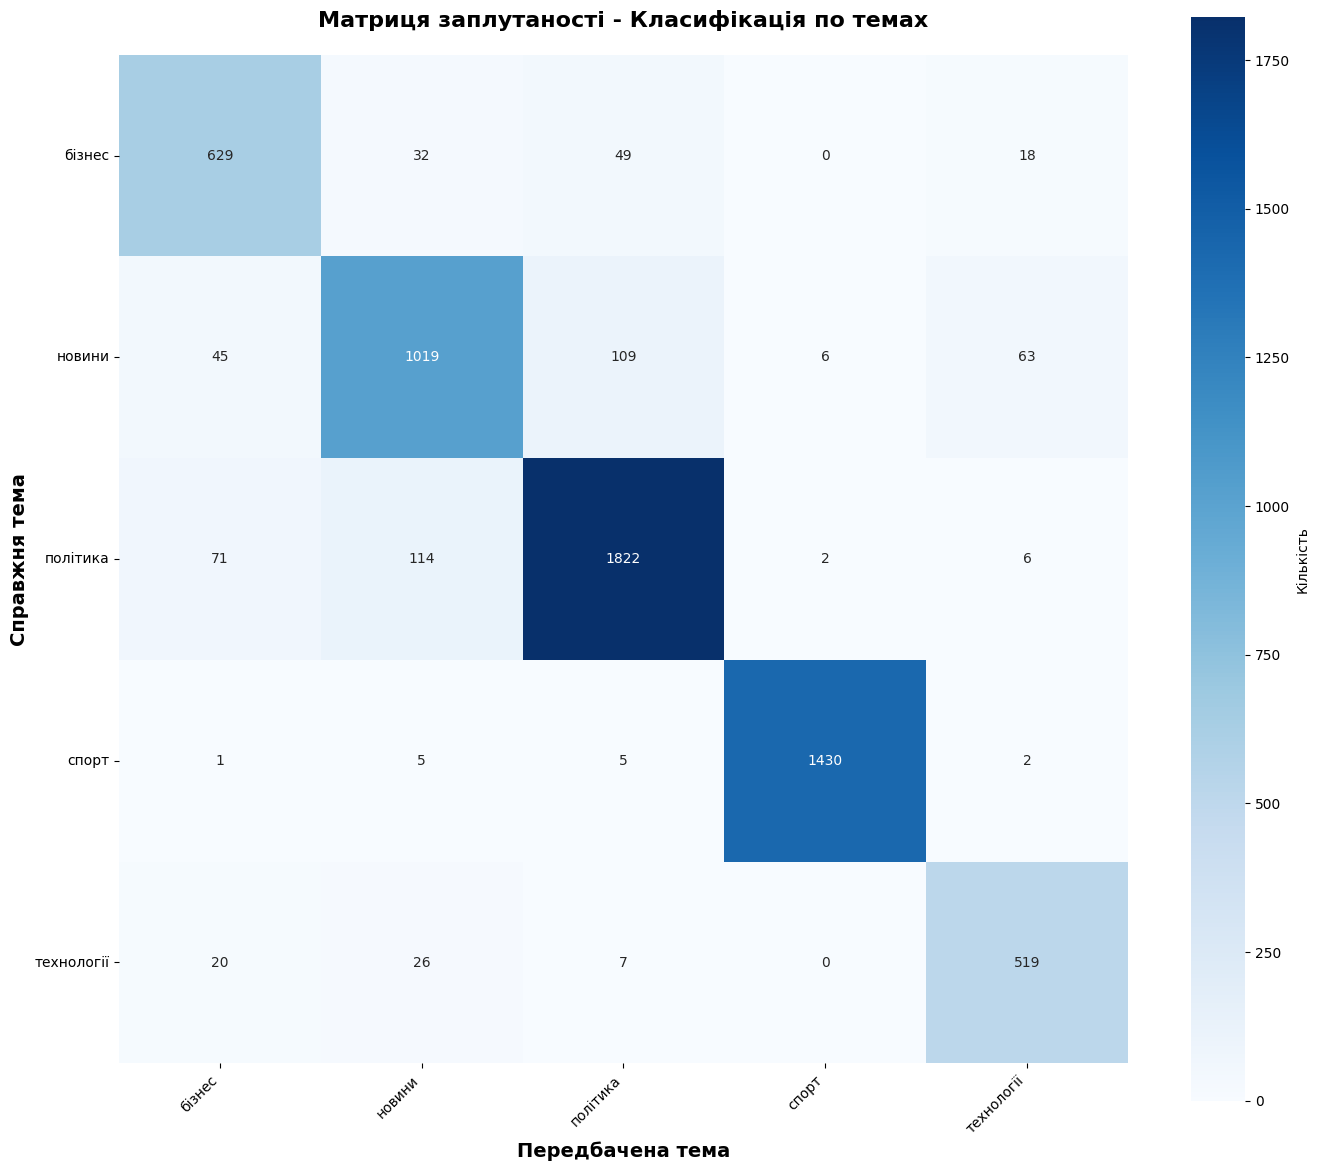


ДЕТАЛЬНА СТАТИСТИКА ПО КОЖНІЙ ТЕМІ
бізнес               | Правильно:  629 /  728 | Точність: 86.40%
новини               | Правильно: 1019 / 1242 | Точність: 82.05%
політика             | Правильно: 1822 / 2015 | Точність: 90.42%
спорт                | Правильно: 1430 / 1443 | Точність: 99.10%
технології           | Правильно:  519 /  572 | Точність: 90.73%


In [20]:
cm = confusion_matrix(Y_test, X_test_pred)

unique_classes = sorted(np.unique(Y))
print(f"\nКількість класів (тем): {len(unique_classes)}")
print(f"Теми: {unique_classes}")

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=unique_classes,
    yticklabels=unique_classes,
    cbar_kws={'label': 'Кількість'},
    square=True
)
plt.title('Матриця заплутаності - Класифікація по темах', fontsize=16, weight='bold', pad=20)
plt.ylabel('Справжня тема', fontsize=14, weight='bold')
plt.xlabel('Передбачена тема', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ДЕТАЛЬНА СТАТИСТИКА ПО КОЖНІЙ ТЕМІ")
print("="*70)
for i, theme in enumerate(unique_classes):
    correct = cm[i][i]
    total = cm[i].sum()
    accuracy = correct / total * 100 if total > 0 else 0
    print(f"{theme:20} | Правильно: {correct:4} / {total:4} | Точність: {accuracy:.2f}%")
print("="*70)

In [21]:
sentence = "Своя праска ближча до тіла. Українські бренди завойовують нижній ціновий сегмент побутової техніки , Національні бренди побутової техніки та електроніки не тільки нарощують продажі в Україні, але вийшли вже й на зовнішні ринки, пише журнал НВ  Ужовтні 2018 року на вітчизняному ТБ крутили ролик про смішного чолов’ягу, зацикленого на придбанні нового телевізора. Замість компліментів дружині він торочив про діагоналі, кумедна собачка викликала у нього думки про процесор, а занурюючись у теплу ванну, він млосним голосом вимовляв назву операційної системи.Ролик, призначений для національних споживачів, присвятили цифровому телевізору марки KIVI. Під такою екзотичною і дещо фруктовою назвою продає свої товари вітчизняна компанія Kindle Vision, що розміщує замовлення у Китаї.Справи у цього виробника йдуть відмінно: бренд став гравцем № 1 серед українських брендів. Такі дані НВ озвучили в прес-службі одного з найбільших продавців побутової техніки й електроніки у країні.Аби досягти такого помітного успіху, KIVI знадобилося всього два роки — бренд з’явився у 2016-му. Євген Руденко, співзасновник KIVI, пояснив НВ: плануючи випуск своїх пристроїв, його компанія орієнтувалася на дві технології, які розвивають ринок телевізорів. Перша — це смарт-ТВ, тобто можливість виходу в інтернет. Друга — HD-роздільна здатність екрану: чим вона вища, тим емоційніша картинка. «Ми подивилися, що в цьому сегменті крім LG і Samsung — а у них дорогий продукт — на ринку нічого немає», — розповів Руденко.Телевізори KIVI — далеко не єдиний приклад. У країні успішно продається ще з десяток місцевих брендів, які переховуються під «імпортними» назвами і, як правило, розміщують замовлення на виробництво у Китаї. Так, велику і дрібну побутову техніку роблять Mirta, Saturn і Prime, витяжки — Pyramida, електро- і газові плити — Greta, обігрівачі — Atlantic і Stinex, вентилятори — Vents.Українці до сегменту високотехнологічних виробів зі своїми марками найчастіше не лізуть, вважаючи за краще насичувати національний ринок побутовими приладами. Основний козир такої продукції — демократична ціна.І він грає: продажі українських марок незмінно зростають, говорять представники торгових мереж. Наприклад, у відділі побутової техніки мережі Епіцентр К сьогодні кожен п’ятий проданий товар припадає на продукцію вітчизняних брендів.Олександр Величко з Епіцентру К розповідає: цьогоріч мережа продала майже на 11% більше українських товарів, ніж у 2018-му. А в деяких категоріях місцеві бренди вже стали № 1. Так, наприклад, сталося у сегменті кліматичної техніки, де панує компанія Vents, зареєстрована в Боярці під Києвом і там таки має виробництво.У Фокстроті — а це мережа-лідер у сфері торгівлі побутовою технікою й електронікою у країні — частка вітчизняної продукції становить уже 10%. «Ми спостерігаємо тенденцію до збільшення попиту і прогнозуємо до кінця року надбавку до 12%», — каже Юрій Поліщук, комерційний директор Фокстроту.Торгові мережі також продають техніку під власними марками, замовляючи товар у Китаї. У Фокстроті це телевізори Bravis і побутові прилади Delfa. Подібна продукція надходить до покупця без посередників і дистриб’юторів, що дозволяє тримати невисоку ціну. «Це приваблює споживачів і утримує стабільне зростання попиту на 1−2% на рік», — зазначає Поліщук. UA замість RU П ідприємець Артем Лукашев до кризи 2008 року працював на позиції топ-менеджера в українському представництві корейської компанії LG. У період економічної нестабільності він зауважив, що співвітчизники перестали гнатися за гучними іменами і почали вибирати пристрої за їх функціональністю. «Ми з партнером [який також працював у LG] побачили в цьому можливість», — згадує Лукашев. Пара бізнесменів націлилася на нижній ціновий сегмент побутової техніки, інвестувавши у виробництво $350 тис. Так з’явилася компанія Mirta, в асортименті якої зараз є все що завгодно: чайники, духовки, плити, мультиварки, кухонні комбайни та багато іншого.Те, що у Лукашева настільки помітно зріс асортимент, виглядає цілком логічно, адже і ринок збільшується. У першому півріччі 2019 року продажі великої побутової техніки, за даними дослідницької компанії GfK, зросли на 17%, дрібної — на 18%.Стимулюють цей процес, за словами співзасновника Mirta, прискорення продажів недорогих продуктів у всіх сегментах. А саме там керують балом національні бренди.Так, якщо вітчизняний електрочайник Saturn обійдеться покупцеві у суму від 200 грн, а Mirta або Magio — від 300 грн, то ціна на аналогічний товар світових брендів — Gorenje, Philips або Bosch — стартує від 500 грн. Окрім того, функціоналом всі ці чайники не відрізняються. Тому покупець, дисциплінований низкою криз і падінням курсу гривні, все частіше віддає перевагу «своїм».До того ж іноземці, які виробляють продукцію верхнього цінового сегмента — так званого А-класу, — ще й знизили в останні роки свою маркетингову активність. І в цьому теж присутня логіка: через девальвацію національної валюти гривневі ціни на імпортні товари злетіли і споживачі логічно відвернулися від дорогих продуктів.У підсумку, наприклад, телевізори марок Philips, Panasonic, Sharp і Toshiba з ринку не пішли, і в продажу вони є. Але, як зазначає Поліщук із Фокстроту, ці транснаціональні бренди перестали вкладати кошти в Україну — робити промо, оголошувати цінові акції, хоча раніше активно цим займалися.Іноземці «пригальмували», і цим одразу скористався KIVI зі своїми смарт-телевізорами. Ціни на них стартують із 6,2 тис. грн для панелей із діагоналлю 40 дюймів. У Philips і Sharp вартість аналогічного продукту починається із 7 тис. грн, а у Panasonic — із 11 тис. грн.Зміцнити позиції недорогим українським брендам допоміг бойкот українських споживачів проти вироблених у Росії товарів.Багато глобальних компаній, які випускали на своїх російських заводах продукцію для України, після 2014-го були змушені змінювати схему постачання. «У період, коли глобальні бренди перерозподіляли постачання із Росії на заводи в інших країнах, були перебої», — розповідає Поліщук. І тимчасово звільнені ніші атакували українські марки.Імідж країни-агресора негативно відбився і на продажах в Україні колись популярних російських бюджетних брендів побутової техніки — Vitek, Scarlett, Polaris. «Відійшли росіяни, які відкушували істотну частину ринку, — розповідає Лукашев із Mirta. — Їх ще можна зустріти у наших магазинах, але продаються вони не дуже добре проти того, що було раніше».А от продажі Mirta зростають: за словами Лукашева, останні кілька років надбавка становила 10−15% річних. А за підсумками 2019 року він очікує плюс 30%. Особливості національної техніки Місцеві гравці беруть покупця за гаманець не тільки своєю доступністю, а й умінням тонше підлаштуватися під локальні тренди.Наприклад, у 2013-му в Україні увійшов у моду яскравий дизайн інтер'єрів. І компанія Pyramida випустила на ринок витяжки червоного кольору. «Спочатку вони [споживачі] могли купити товар такої кольорової гами тільки у нас», — розповідає Костянтин Михайленко, комерційний директор Pyramida.Український бренд, за словами топ-менеджера, здатен досить швидко виводити нові товарні позиції, й цим він відрізняється від світових виробників, у яких кожне рішення проходить багато етапів погоджень. Тому Pyramida, як зазначив Михайленко, для запуску нової моделі — від моменту прийняття рішення до появи у роздрібі — потрібно п’ять-шість місяців, а транснаціональним брендам — від року. Внаслідок зі 120 тис. проданих за рік витяжок вітчизняна компанія завоювала третину національного ринку.У Mirta теж є схожа історія: у 2011-му фірма зважилася обладнати свої кухонні комбайни насадками для дерунів. «Ми були першими, хто почав це робити на нашому ринку. Потім і решта підтяглися», — каже Лукашев.Ще одне вдале рішення — прес для томатів, яким Mirta стала комплектувати свої м’ясорубки. Тепер 90% товарів цієї категорії на ринку оснащують подібною насадкою. Замінити Китай Більшу частину техніки вітчизняних брендів виробляють аж ніяк не в Україні, а в Китаї та інших країнах Південно-Східної Азії. Там є високотехнологічне виробництво у великих обсягах, говорить Поліщук з Фокстроту, що дає можливість отримувати конкурентний продукт за доступною ціною.Втім, деякі свої потужності українці стали розміщувати вже і на батьківщині. Так, компанія KTD Group, що випускає товари під маркою Saturn, спочатку всю свою продукцію замовляла в Піднебесній. Але з часом, як розповів засновник KTD Group Олександр Громико, відкрила завод у Каневі, де тепер робить частину своєї продукції. А чотири роки тому Громико купив ще й проммайданчик у Черкасах, на якому планує виробляти холодильники.Своє виробництво в Україні та у компанії Greta, яка збирає на Донбасі (у Дружківці) кухонні плити. За словами Володимира Нещеретова, заступника гендиректора Greta зі збуту, вони б і раді повністю замкнути виробництво на батьківщині, але для цього потрібні суміжні виробництва, яких у країні немає. Тому зараз до 80% комплектування Greta закуповує за кордоном.Водночас українці примудрилися не тільки завоювати свій ринок, але і вийти за межі країни. Так, із 200 тис. плит, які Greta виробляє за рік, близько 70 тис. піде — за підсумками 2019-го — у країни Балтії, Польщу, Румунію, Чехію та Угорщину. Крім того, експорт зростає: у 2016-му Дружківська компанія продавала на зовнішні ринки лише 26 тис. плит, а торік — 55 тис.Вивозить із країни свою продукцію і Pyramida: кожна п’ята витяжка бренду йде на ринки Білорусі, Казахстану, Молдови, Грузії, Росії, Вірменії, Азербайджану та навіть ОАЕ."

sentence = filtering(sentence)
sentence = lemmatize_text(sentence)
X = vectorizer.transform([sentence])
prediction = model_theme.predict(X)
print(f"Категорія: {prediction[0]}")

Категорія: бізнес


In [22]:
import pickle

with open('theme_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('theme_model.pkl', 'wb') as f:
    pickle.dump(model_theme, f)